# BROUILLON D'ESSAIS — Modeling Experiments
## Return/Refund Propensity Classification (Olist)

Ce notebook sert uniquement a tester plusieurs configurations d'algorithmes.
Les meilleures configurations sont ensuite reportees dans `02_Modeling.ipynb`.

---
### Plan d'essais
1. Chargement & preprocessing
2. Essais multi-configurations (LogReg, Decision Tree, Random Forest, XGBoost)
3. Tableau comparatif des essais
4. Selection des meilleures configurations

## 1. Imports & Chargement

In [19]:
# --- Librairies ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os
import joblib  # Pour sauvegarder le modèle final

# --- Machine Learning : Modèles ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# XGBoost (bonus — commenter si non installé)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️  XGBoost non installé — pip install xgboost')

# --- Machine Learning : Optimisation & Évaluation ---
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score
)

# --- Configuration ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42  # Graine aléatoire pour la reproductibilité

# Ajouter le dossier racine au PATH
sys.path.append(os.path.abspath('..'))

print('✅ Imports réussis')

✅ Imports réussis


In [20]:
# Charger le DataFrame maître depuis data_loader
from src.data_loader import load_data

df = load_data(data_dir='../data')
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

📂 Chargement des fichiers CSV...
  ✅ orders          —  99,441 lignes | 8 colonnes
  ✅ items           — 112,650 lignes | 7 colonnes
  ✅ payments        — 103,886 lignes | 5 colonnes
  ✅ reviews         —  99,224 lignes | 7 colonnes
  ✅ customers       —  99,441 lignes | 5 colonnes
  ✅ sellers         —   3,095 lignes | 4 colonnes
  ✅ products        —  32,951 lignes | 9 colonnes
  ✅ geolocation     — 1,000,163 lignes | 5 colonnes
  ✅ translation     —      71 lignes | 2 colonnes

🔗 Fusion des tables...

✅ DataFrame maître construit : 99,441 lignes × 22 colonnes
Dataset chargé : 99,441 lignes × 22 colonnes


---
## 2. Preprocessing Complet

On utilise le pipeline de `src/preprocessing.py` qui enchaîne automatiquement toutes les étapes.

In [21]:
from src.preprocessing import full_preprocessing_pipeline

# Lance le pipeline complet : nettoyage → feature engineering → encodage → split → normalisation
X_train, X_test, y_train, y_test, scaler = full_preprocessing_pipeline(df)

print(f'\nX_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')

PIPELINE DE PREPROCESSING

📅 Conversion des dates...
  ✅ 5 colonnes converties en datetime

🔍 Filtrage des commandes valides...
  ✅ 1,729 commandes hors périmètre supprimées → 97,712 commandes restantes

🧹 Gestion des valeurs manquantes...
  ✅ product_weight_g: 783 NaN → médiane (700.00)
  ✅ product_photos_qty: 2140 NaN → médiane (2.00)
  ✅ total_price: 767 NaN → médiane (86.80)
  ✅ total_freight: 767 NaN → médiane (17.16)
  ✅ payment_value: 1 NaN → médiane (105.28)
  ✅ payment_installments: 1 NaN → médiane (2.00)
  ✅ item_count: 767 NaN → médiane (1.00)
  ✅ product_category_name_english: 2161 NaN → 'unknown'
  ✅ payment_type: 1 NaN → 'unknown'

⚙️  Feature Engineering...
  ✅ 8 nouvelles features créées : delivery_delay_days, processing_days, freight_ratio, price_per_item, was_delivered, review_missing, purchase_month, purchase_day_of_week

  Distribution de la variable cible (is_return_refund_risk) :
    Risque élevé (1) :  13,506 (13.8%)
    Risque faible(0) :  84,206 (86.2%)

🔡 Enco

In [22]:
# Vérification du déséquilibre dans le train set
print('Distribution des classes dans y_train :')
print(y_train.value_counts())
print(f'\nRatio : {y_train.value_counts()[1] / y_train.value_counts()[0]:.2f}:1')

# NOTE : on utilisera class_weight='balanced' dans les modèles pour compenser

Distribution des classes dans y_train :
is_return_refund_risk
0    67364
1    10805
Name: count, dtype: int64

Ratio : 0.16:1


---
## 3. Modèle 1 — Régression Logistique (Baseline)

Baseline pour Return/Refund propensity avant essais multi-paramètres.

In [23]:
print('=' * 50)
print('MODELE 1 - REGRESSION LOGISTIQUE')
print('=' * 50)

lr = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs'
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'\n{classification_report(y_test, y_pred_lr, target_names=["Low Risk", "High Risk"])}')

MODELE 1 - REGRESSION LOGISTIQUE

Accuracy  : 0.7695
F1-Score  : 0.7955
AUC-ROC   : 0.7413

              precision    recall  f1-score   support

    Low Risk       0.92      0.80      0.86     16842
   High Risk       0.32      0.59      0.41      2701

    accuracy                           0.77     19543
   macro avg       0.62      0.69      0.64     19543
weighted avg       0.84      0.77      0.80     19543



---
## 4. Modèle 2 — Arbre de Décision

Baseline non linéaire pour Return/Refund propensity.

In [24]:
print('=' * 50)
print('MODELE 2 - ARBRE DE DECISION')
print('=' * 50)

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    criterion='gini'
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_dt):.4f}')
print(f'\n{classification_report(y_test, y_pred_dt, target_names=["Low Risk", "High Risk"])}')

MODELE 2 - ARBRE DE DECISION

Accuracy  : 0.8290
F1-Score  : 0.8391
AUC-ROC   : 0.7604

              precision    recall  f1-score   support

    Low Risk       0.92      0.87      0.90     16842
   High Risk       0.41      0.55      0.47      2701

    accuracy                           0.83     19543
   macro avg       0.67      0.71      0.69     19543
weighted avg       0.85      0.83      0.84     19543



  ✅ 5 colonnes converties en datetime
  ✅ 1,729 commandes hors périmètre supprimées → 97,712 commandes restantes
  ✅ product_weight_g: 783 NaN → médiane (700.00)
  ✅ product_photos_qty: 2140 NaN → médiane (2.00)
  ✅ total_price: 767 NaN → médiane (86.80)
  ✅ total_freight: 767 NaN → médiane (17.16)
  ✅ payment_value: 1 NaN → médiane (105.28)
  ✅ payment_installments: 1 NaN → médiane (2.00)
  ✅ item_count: 767 NaN → médiane (1.00)
  ✅ product_category_name_english: 2161 NaN → 'unknown'
  ✅ payment_type: 1 NaN → 'unknown'
  ✅ 8 nouvelles features créées : delivery_delay_days, processing_days, freight_ratio, price_per_item, was_delivered, review_missing, purchase_month, purchase_day_of_week

  Distribution de la variable cible (is_return_refund_risk) :
    Risque élevé (1) :  13,506 (13.8%)
    Risque faible(0) :  84,206 (86.2%)
  ✅ payment_type encodé → payment_type_encoded (6 modalités)
  ✅ customer_state encodé → customer_state_encoded (27 modalités)
  ✅ product_category_name_english e

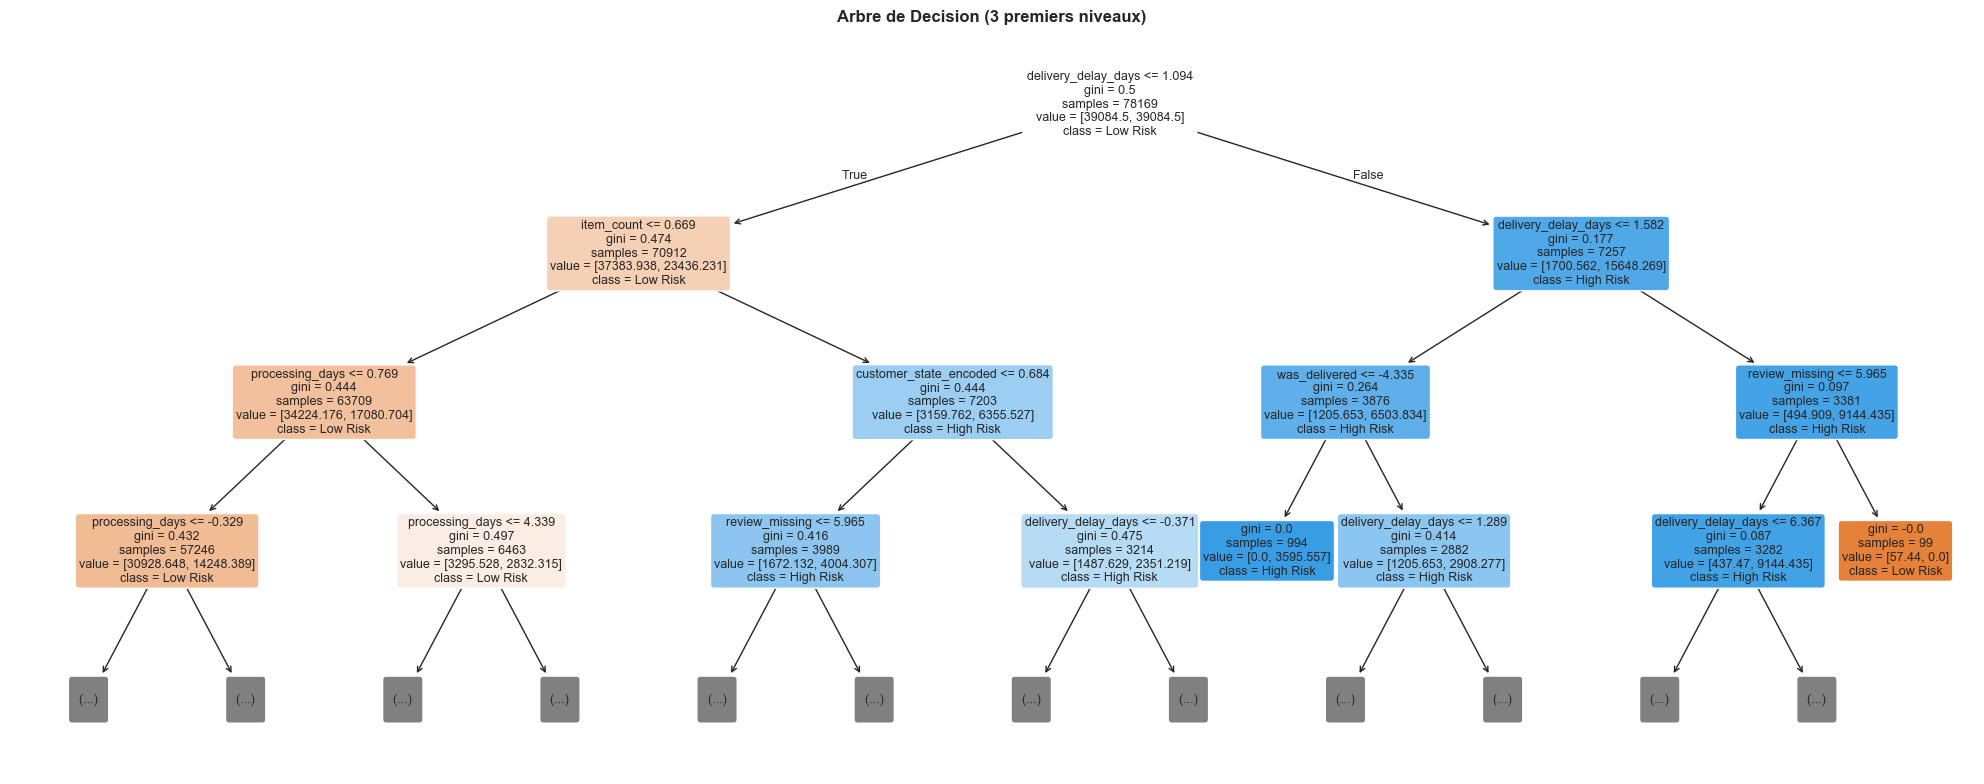

In [25]:
# Visualisation des 3 premiers niveaux de l'arbre
from src.preprocessing import (
    convert_dates, filter_valid_orders, handle_missing_values,
    create_features, create_return_refund_target, encode_categorical, select_features
)

df_temp = convert_dates(df.copy())
df_temp = filter_valid_orders(df_temp)
df_temp = handle_missing_values(df_temp)
df_temp = create_features(df_temp)
df_temp = create_return_refund_target(df_temp)
df_temp = encode_categorical(df_temp)
X_named, _ = select_features(df_temp)
feature_names = X_named.columns.tolist()

plt.figure(figsize=(20, 8))
plot_tree(
    dt, max_depth=3,
    feature_names=feature_names,
    class_names=['Low Risk', 'High Risk'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Arbre de Decision (3 premiers niveaux)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Modèle 3 — Random Forest

Baseline ensembliste pour Return/Refund propensity.

In [26]:
print('=' * 50)
print('MODELE 3 - RANDOM FOREST')
print('=' * 50)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=30,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=["Low Risk", "High Risk"])}')

MODELE 3 - RANDOM FOREST

Accuracy  : 0.8524
F1-Score  : 0.8562
AUC-ROC   : 0.7738

              precision    recall  f1-score   support

    Low Risk       0.92      0.90      0.91     16842
   High Risk       0.47      0.53      0.50      2701

    accuracy                           0.85     19543
   macro avg       0.70      0.72      0.71     19543
weighted avg       0.86      0.85      0.86     19543



---
## 6. Modèle 4 — XGBoost

Baseline boosting pour Return/Refund propensity.

In [27]:
if XGBOOST_AVAILABLE:
    print('=' * 50)
    print('MODELE 4 - XGBOOST')
    print('=' * 50)

    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos_weight = neg_count / max(pos_count, 1)

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
)

    xgb.fit(X_train, y_train)

    y_pred_xgb = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

    print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}')
    print(f'F1-Score  : {f1_score(y_test, y_pred_xgb, average="weighted"):.4f}')
    print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_xgb):.4f}')
    print(f'\n{classification_report(y_test, y_pred_xgb, target_names=["Low Risk", "High Risk"])}')
else:
    print('XGBoost non disponible. Installer avec : pip install xgboost')

MODELE 4 - XGBOOST

Accuracy  : 0.8349
F1-Score  : 0.8443
AUC-ROC   : 0.7709

              precision    recall  f1-score   support

    Low Risk       0.93      0.88      0.90     16842
   High Risk       0.43      0.57      0.49      2701

    accuracy                           0.83     19543
   macro avg       0.68      0.72      0.69     19543
weighted avg       0.86      0.83      0.84     19543



---
## 7. Comparaison des Modèles


📊 Tableau Comparatif des Modèles :
         model_name  accuracy       f1      auc
      Random Forest  0.852428 0.856202 0.773819
            XGBoost  0.834928 0.844258 0.770934
      Decision Tree  0.829044 0.839145 0.760429
Logistic Regression  0.769534 0.795461 0.741322


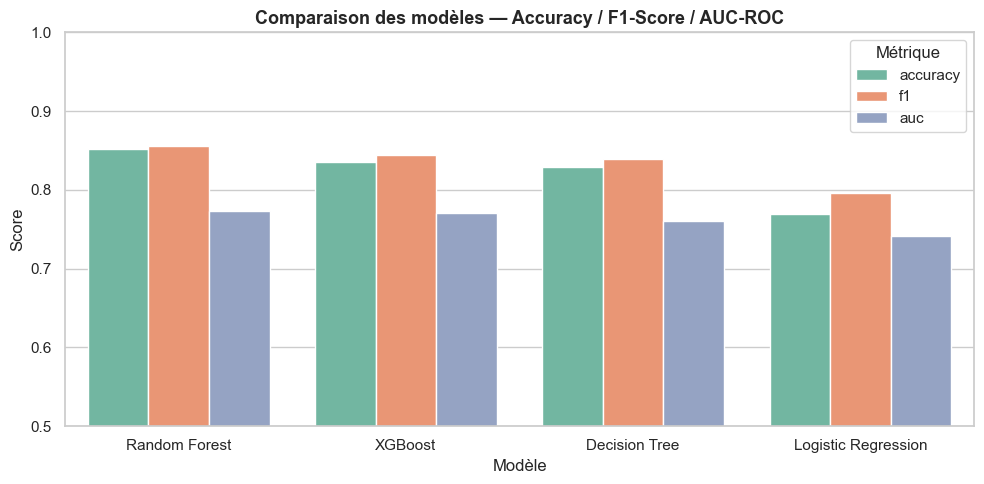

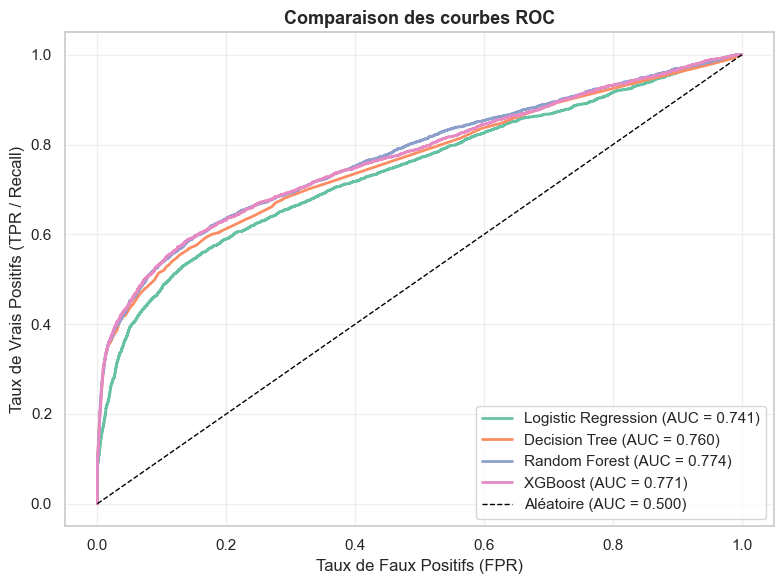

In [28]:
from src.evaluation import compare_models, plot_roc_curves

# Compilation des résultats de tous les modèles
results = [
    {'model_name': 'Logistic Regression',
     'accuracy': accuracy_score(y_test, y_pred_lr),
     'f1':       f1_score(y_test, y_pred_lr, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_lr)},

    {'model_name': 'Decision Tree',
     'accuracy': accuracy_score(y_test, y_pred_dt),
     'f1':       f1_score(y_test, y_pred_dt, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_dt)},

    {'model_name': 'Random Forest',
     'accuracy': accuracy_score(y_test, y_pred_rf),
     'f1':       f1_score(y_test, y_pred_rf, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_rf)},
]

if XGBOOST_AVAILABLE:
    results.append({
        'model_name': 'XGBoost',
        'accuracy': accuracy_score(y_test, y_pred_xgb),
        'f1':       f1_score(y_test, y_pred_xgb, average='weighted'),
        'auc':      roc_auc_score(y_test, y_proba_xgb)
    })

df_results = compare_models(results)

# Courbes ROC comparatives
models_dict = {
    'Logistic Regression': lr,
    'Decision Tree':       dt,
    'Random Forest':       rf,
}
if XGBOOST_AVAILABLE:
    models_dict['XGBoost'] = xgb

plot_roc_curves(models_dict, X_test, y_test)

---
## 8. Essais multiples d'hyperparametres

On teste plusieurs configurations pour chaque algorithme.
Objectif: comparer les scores et retenir la meilleure version par algorithme.

In [ ]:
from sklearn.base import clone

def score_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'auc': roc_auc_score(y_test, y_proba),
    }

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / max(pos_count, 1)

# Anciennes configurations du notebook principal (archivées, non scorées dans les trials)
former_modeling_configs = {
    'DecisionTree_main_old': DecisionTreeClassifier(max_depth=8, min_samples_split=50, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest_main_old': RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_split=30, min_samples_leaf=10, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
}
if XGBOOST_AVAILABLE:
    former_modeling_configs['XGBoost_main_old'] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0
    )

trial_bank = {
    'LogReg': [
        # Trial 1 (retenu dans 02_Modeling)
        LogisticRegression(max_iter=500, class_weight='balanced', C=1.0, solver='lbfgs', random_state=RANDOM_STATE),
        LogisticRegression(max_iter=700, class_weight='balanced', C=0.5, solver='lbfgs', random_state=RANDOM_STATE),
        LogisticRegression(max_iter=800, class_weight='balanced', C=2.0, solver='lbfgs', random_state=RANDOM_STATE),
    ],
    'DecisionTree': [
        # Trial 1 (retenu dans 02_Modeling)
        DecisionTreeClassifier(max_depth=6, min_samples_split=50, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
        DecisionTreeClassifier(max_depth=8, min_samples_split=40, min_samples_leaf=15, class_weight='balanced', random_state=RANDOM_STATE),
        DecisionTreeClassifier(max_depth=12, min_samples_split=30, min_samples_leaf=10, class_weight='balanced', random_state=RANDOM_STATE),
    ],
    'RandomForest': [
        RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=40, min_samples_leaf=15, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        # Ancienne config du notebook principal (equivaut a l'ancien modele principal)
        RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_split=30, min_samples_leaf=10, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        # Trial 3 (retenu dans 02_Modeling)
        RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_split=20, min_samples_leaf=5, max_features='log2', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    ],
}

if XGBOOST_AVAILABLE:
    trial_bank['XGBoost'] = [
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
        # Ancienne config du notebook principal (equivaut a l'ancien modele principal)
        XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
        # Trial 3 (retenu dans 02_Modeling)
        XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.7, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    ]

trial_rows = []
best_by_algo = {}

for algo_name, configs in trial_bank.items():
    print(f'\n===== {algo_name} =====')
    best_f1 = -1
    best_model = None
    best_idx = None

    for i, model in enumerate(configs, start=1):
        metrics = score_model(model, X_train, y_train, X_test, y_test)
        row = {
            'algorithm': algo_name,
            'trial_id': i,
            'accuracy': metrics['accuracy'],
            'f1': metrics['f1'],
            'auc': metrics['auc'],
            'params': str(model.get_params()),
        }
        trial_rows.append(row)
        print(f"Trial {i}: F1={metrics['f1']:.4f} | AUC={metrics['auc']:.4f} | ACC={metrics['accuracy']:.4f}")

        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_model = clone(model)
            best_idx = i

    best_model.fit(X_train, y_train)
    best_by_algo[algo_name] = {'trial_id': best_idx, 'model': best_model, 'f1': best_f1}

df_trials = pd.DataFrame(trial_rows).sort_values(['algorithm', 'f1'], ascending=[True, False])
df_trials.head(20)


===== LogReg =====
Trial 1: F1=0.7955 | AUC=0.7413 | ACC=0.7695
Trial 2: F1=0.7953 | AUC=0.7414 | ACC=0.7693
Trial 3: F1=0.7954 | AUC=0.7414 | ACC=0.7694

===== DecisionTree =====
Trial 1: F1=0.8456 | AUC=0.7632 | ACC=0.8377
Trial 2: F1=0.8391 | AUC=0.7598 | ACC=0.8290
Trial 3: F1=0.8235 | AUC=0.7308 | ACC=0.8089

===== RandomForest =====
Trial 1: F1=0.8479 | AUC=0.7735 | ACC=0.8408
Trial 2: F1=0.8560 | AUC=0.7744 | ACC=0.8522
Trial 3: F1=0.8727 | AUC=0.7741 | ACC=0.8791

===== XGBoost =====
Trial 1: F1=0.8443 | AUC=0.7709 | ACC=0.8349
Trial 2: F1=0.8454 | AUC=0.7752 | ACC=0.8364
Trial 3: F1=0.8570 | AUC=0.7670 | ACC=0.8542


,algorithm,trial_id,accuracy,f1,auc,params
3,DecisionTree,1,0.837691,0.845555,0.763207,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
4,DecisionTree,2,0.828992,0.839105,0.759791,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
5,DecisionTree,3,0.808934,0.823461,0.730842,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
0,LogReg,1,0.769534,0.795461,0.741322,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."
2,LogReg,3,0.769432,0.795383,0.741395,"{'C': 2.0, 'class_weight': 'balanced', 'dual':..."
1,LogReg,2,0.769329,0.795305,0.741363,"{'C': 0.5, 'class_weight': 'balanced', 'dual':..."
8,RandomForest,3,0.879138,0.872744,0.774106,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
7,RandomForest,2,0.852223,0.856022,0.774420,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
6,RandomForest,1,0.840813,0.847860,0.773506,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
11,XGBoost,3,0.854168,0.856969,0.766985,"{'objective': 'binary:logistic', 'base_score':..."


In [30]:
print('Meilleure configuration par algorithme :')
for algo, info in best_by_algo.items():
    print(f"- {algo}: trial #{info['trial_id']} (F1={info['f1']:.4f})")

best_overall_algo = max(best_by_algo.keys(), key=lambda k: best_by_algo[k]['f1'])
best_overall_model = best_by_algo[best_overall_algo]['model']
print(f"\nMeilleur modele global du brouillon: {best_overall_algo}")

y_pred_best_trial = best_overall_model.predict(X_test)
y_proba_best_trial = best_overall_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_best_trial):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_trial, average='weighted'):.4f}")
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_best_trial):.4f}")
print(classification_report(y_test, y_pred_best_trial, target_names=['Low Risk', 'High Risk']))

Meilleure configuration par algorithme :
- LogReg: trial #1 (F1=0.7955)
- DecisionTree: trial #1 (F1=0.8456)
- RandomForest: trial #3 (F1=0.8727)
- XGBoost: trial #3 (F1=0.8570)

Meilleur modele global du brouillon: RandomForest
Accuracy: 0.8791
F1-Score: 0.8727
AUC-ROC : 0.7741
              precision    recall  f1-score   support

    Low Risk       0.92      0.95      0.93     16842
   High Risk       0.58      0.45      0.51      2701

    accuracy                           0.88     19543
   macro avg       0.75      0.70      0.72     19543
weighted avg       0.87      0.88      0.87     19543



---
## 9. Analyse des Features Importantes (Return/Refund)

Analyse des variables les plus contributives pour le meilleur modèle issu des essais.

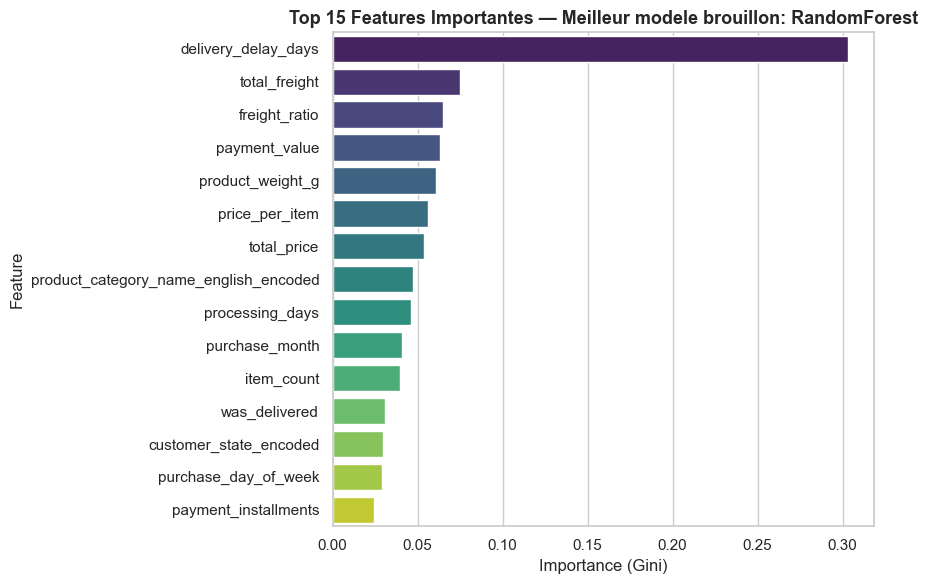

In [31]:
from src.evaluation import plot_feature_importance

# Important: on utilise le meilleur modele du brouillon, pas best_rf du notebook final
plot_feature_importance(
    best_overall_model,
    feature_names,
    model_name=f'Meilleur modele brouillon: {best_overall_algo}',
    top_n=15
)

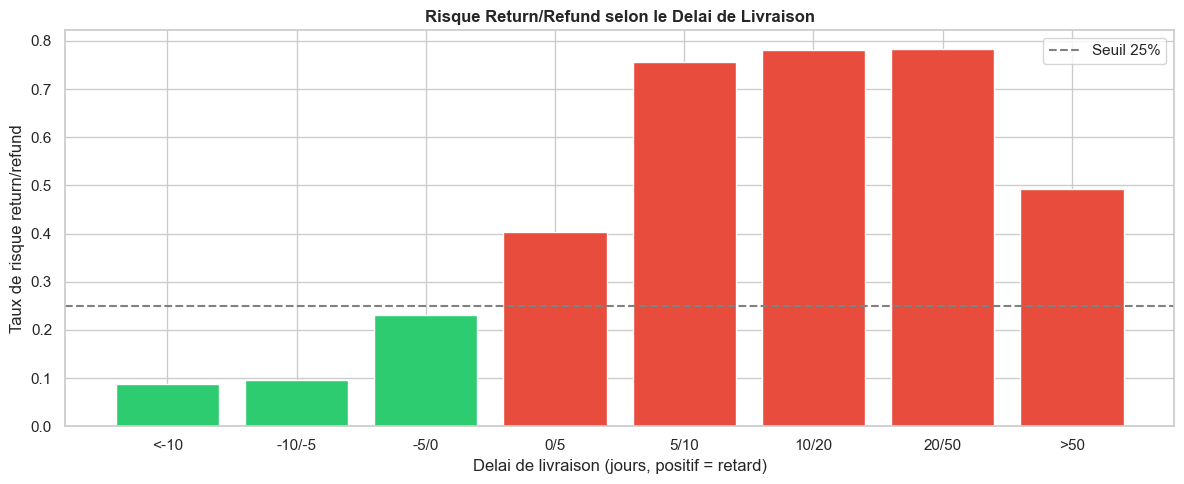


Insight: plus le retard augmente, plus le risque return/refund monte.


In [32]:
# Analyse: risque return/refund selon le delai de livraison
df_analysis = df_temp[df_temp['delivery_delay_days'].notna()].copy()

bins = [-30, -10, -5, 0, 5, 10, 20, 50, 100]
labels = ['<-10', '-10/-5', '-5/0', '0/5', '5/10', '10/20', '20/50', '>50']
df_analysis['delay_bucket'] = pd.cut(df_analysis['delivery_delay_days'], bins=bins, labels=labels)

risk_by_delay = df_analysis.groupby('delay_bucket')['is_return_refund_risk'].mean()

plt.figure(figsize=(12, 5))
plt.bar(
    risk_by_delay.index,
    risk_by_delay.values,
    color=['#e74c3c' if v > 0.25 else '#2ecc71' for v in risk_by_delay.values]
 )
plt.axhline(y=0.25, color='gray', linestyle='--', label='Seuil 25%')
plt.xlabel('Delai de livraison (jours, positif = retard)')
plt.ylabel('Taux de risque return/refund')
plt.title('Risque Return/Refund selon le Delai de Livraison', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('\nInsight: plus le retard augmente, plus le risque return/refund monte.')

---
## 10. Analyse des Erreurs (Return/Refund)

On analyse les erreurs du meilleur modèle du brouillon.
- Faux Positifs: commandes low risk predites high risk (sur-allocation d'actions)
- Faux Negatifs: commandes high risk predites low risk (risque business)

Dans ce cas d'usage, les faux negatifs sont souvent les plus couteux.

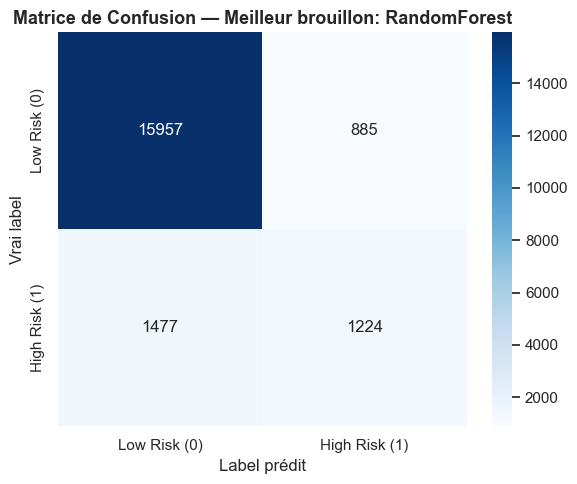

In [33]:
from src.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    best_overall_model,
    X_test,
    y_test,
    model_name=f'Meilleur brouillon: {best_overall_algo}'
)

In [34]:
# Bilan erreurs du meilleur modele du brouillon
y_pred_exp = best_overall_model.predict(X_test)

errors_mask = y_pred_exp != y_test.values
print(f"Nombre total d'erreurs : {errors_mask.sum():,} ({errors_mask.sum()/len(y_test)*100:.1f}%)")

fp = ((y_pred_exp == 1) & (y_test.values == 0)).sum()
fn = ((y_pred_exp == 0) & (y_test.values == 1)).sum()
print(f'  Faux Positifs (FP) : {fp:,}')
print(f'  Faux Negatifs (FN) : {fn:,}')

Nombre total d'erreurs : 2,362 (12.1%)
  Faux Positifs (FP) : 885
  Faux Negatifs (FN) : 1,477


---
## 11. Conclusion des Essais

Ce notebook conserve uniquement les essais d'algorithmes pour
Return/Refund Propensity Classification.

In [35]:
# Tableau final des essais (top 20)
display(
    df_trials.sort_values(['f1', 'auc', 'accuracy'], ascending=False).head(20)
)

print('\nModele recommande pour 02_Modeling.ipynb:')
print(f"- {best_overall_algo} (selon F1 weighted maximal)")

,algorithm,trial_id,accuracy,f1,auc,params
8,RandomForest,3,0.879138,0.872744,0.774106,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
11,XGBoost,3,0.854168,0.856969,0.766985,"{'objective': 'binary:logistic', 'base_score':..."
7,RandomForest,2,0.852223,0.856022,0.774420,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
6,RandomForest,1,0.840813,0.847860,0.773506,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
3,DecisionTree,1,0.837691,0.845555,0.763207,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
10,XGBoost,2,0.836361,0.845367,0.775205,"{'objective': 'binary:logistic', 'base_score':..."
9,XGBoost,1,0.834928,0.844258,0.770934,"{'objective': 'binary:logistic', 'base_score':..."
4,DecisionTree,2,0.828992,0.839105,0.759791,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
5,DecisionTree,3,0.808934,0.823461,0.730842,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
0,LogReg,1,0.769534,0.795461,0.741322,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."



Modele recommande pour 02_Modeling.ipynb:
- RandomForest (selon F1 weighted maximal)


### Decision de transfert vers le notebook final

Reporter dans `02_Modeling.ipynb` uniquement:
1. La meilleure configuration par algorithme si necessaire.
2. Le meilleur modèle global pour la section modèle final.

Le brouillon reste dédié aux essais et comparaisons de paramètres.